# Recommendation Systems for Personalized Content Discovery
## Netflix Prize Dataset — SVD vs Neural Collaborative Filtering
Author: Kumar Manas | kumar_m@me.iitr.ac.in

This notebook builds, evaluates, and compares three recommendation models:
- **SVD** (matrix factorization baseline, mean-centered)
- **NCF v1** (neural CF, no bias terms)
- **NCF v3** (neural CF, bias terms + weight decay + candidate filtering)

Each model is evaluated on **RMSE** (rating prediction) and **MAP@10** (ranking quality,
relevance threshold = rating ≥ 3.5), plus **coverage** and **score variance** as
diversity/personalization diagnostics.

In [1]:
import pandas as pd
import time

def parse_netflix_file(filepath):
    records = []
    current_movie = None
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                current_movie = int(line[:-1])
            else:
                user, rating, date = line.split(',')
                records.append((current_movie, int(user), int(rating), date))
    return records

base_path = '/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/'
files = ['combined_data_1.txt', 'combined_data_2.txt',
         'combined_data_3.txt', 'combined_data_4.txt']

all_records = []
for f in files:
    print(f"Loading {f}...")
    all_records.extend(parse_netflix_file(base_path + f))

df = pd.DataFrame(all_records, columns=['movie_id', 'user_id', 'rating', 'date'])
df['date'] = pd.to_datetime(df['date'])
df['movie_id'] = df['movie_id'].astype('int16')
df['user_id']  = df['user_id'].astype('int32')
df['rating']   = df['rating'].astype('int8')

print(f"\nTotal records: {len(df):,}")
print(f"Unique movies: {df['movie_id'].nunique():,}")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Memory usage after optimization: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading combined_data_1.txt...
Loading combined_data_2.txt...
Loading combined_data_3.txt...
Loading combined_data_4.txt...

Total records: 100,480,507
Unique movies: 17,770
Unique users: 480,189
Date range: 1999-11-11 00:00:00 to 2005-12-31 00:00:00
Memory usage after optimization: 1.51 GB


In [2]:
df['movie_id'] = df['movie_id'].astype('int16')
df['user_id']  = df['user_id'].astype('int32')
df['rating']   = df['rating'].astype('int8')

print(f"Memory usage after optimization: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Memory usage after optimization: 1.51 GB


In [3]:
df.to_parquet('/kaggle/working/netflix_clean.parquet', index=False)
print("Saved.")

Saved.


## 1. Exploratory Data Analysis

### 1.1 Rating Distribution

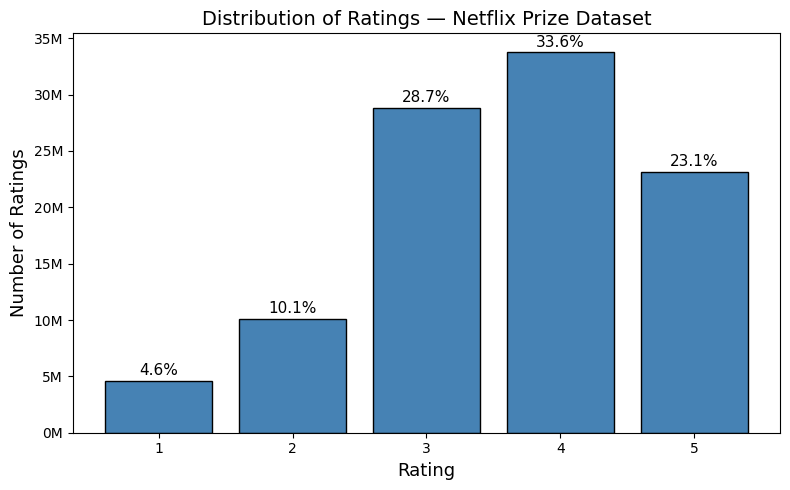


Raw counts:
  1 stars:    4,617,990  (4.6%)
  2 stars:   10,132,080  (10.1%)
  3 stars:   28,811,247  (28.7%)
  4 stars:   33,750,958  (33.6%)
  5 stars:   23,168,232  (23.1%)


In [4]:
import matplotlib.pyplot as plt

rating_counts = df['rating'].value_counts().sort_index()
total = len(df)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')

# Add percentage labels on top of each bar
for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500000,
            f'{count/total*100:.1f}%',
            ha='center', fontsize=11)

ax.set_xlabel('Rating', fontsize=13)
ax.set_ylabel('Number of Ratings', fontsize=13)
ax.set_title('Distribution of Ratings — Netflix Prize Dataset', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('/kaggle/working/rating_distribution.png', dpi=150)
plt.show()

print("\nRaw counts:")
for star, count in rating_counts.items():
    print(f"  {star} stars: {count:>12,}  ({count/total*100:.1f}%)")

**Insight:** 56.7% of ratings are 4-5 stars. This is selection bias, not evidence
that "most movies are good." Users self-select content they expect to like,
the recommendation engine pre-filters likely dislikes, and users who hate a
movie often abandon it without rating it. This skews the training signal
toward over-prediction — models trained on this data will systematically
over-predict ratings, which RMSE alone won't reveal.

### 1.2 Ratings per User

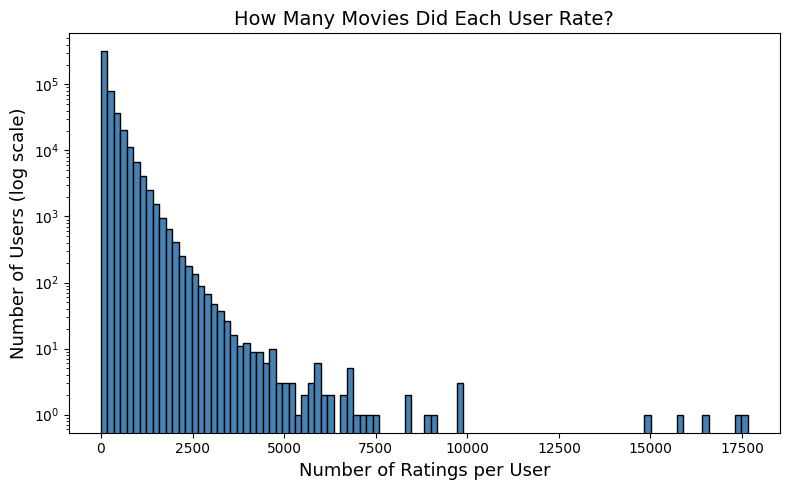

Median ratings per user : 96
Mean ratings per user   : 209
Max ratings per user    : 17,653
Users with < 10 ratings : 16,419  (3.4%)
Users with > 500 ratings: 54,238  (11.3%)


In [5]:
ratings_per_user = df.groupby('user_id')['rating'].count()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ratings_per_user, bins=100, color='steelblue', edgecolor='black', log=True)
ax.set_xlabel('Number of Ratings per User', fontsize=13)
ax.set_ylabel('Number of Users (log scale)', fontsize=13)
ax.set_title('How Many Movies Did Each User Rate?', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/ratings_per_user.png', dpi=150)
plt.show()

print(f"Median ratings per user : {ratings_per_user.median():.0f}")
print(f"Mean ratings per user   : {ratings_per_user.mean():.0f}")
print(f"Max ratings per user    : {ratings_per_user.max():,}")
print(f"Users with < 10 ratings : {(ratings_per_user < 10).sum():,}  ({(ratings_per_user < 10).mean()*100:.1f}%)")
print(f"Users with > 500 ratings: {(ratings_per_user > 500).sum():,}  ({(ratings_per_user > 500).mean()*100:.1f}%)")

**Insight:** Mean (209) is more than double the median (96) — the dataset is
dominated by a minority of power users. The 11.3% of users with >500 ratings
provide the bulk of the training signal, so a model optimized for overall RMSE
will implicitly over-fit to power-user taste at the expense of median users.
This is precisely why MAP@10 is mandated alongside RMSE: it measures ranking
quality per user, regardless of how much data that user contributed.

The single max (17,653 ratings) is almost certainly a shared/family account
or bot — a polluted signal representing multiple people's tastes as one.

### 1.3 Ratings per Movie

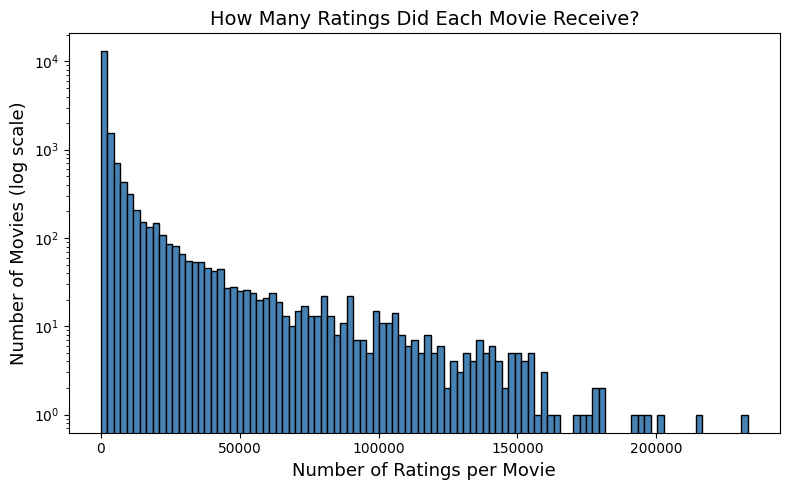

Median ratings per movie : 561
Mean ratings per movie   : 5655
Max ratings per movie    : 232,944
Movies with < 100 ratings: 975  (5.5%)
Movies with > 10k ratings: 2,042  (11.5%)


In [6]:
ratings_per_movie = df.groupby('movie_id')['rating'].count()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ratings_per_movie, bins=100, color='steelblue', edgecolor='black', log=True)
ax.set_xlabel('Number of Ratings per Movie', fontsize=13)
ax.set_ylabel('Number of Movies (log scale)', fontsize=13)
ax.set_title('How Many Ratings Did Each Movie Receive?', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/ratings_per_movie.png', dpi=150)
plt.show()

print(f"Median ratings per movie : {ratings_per_movie.median():.0f}")
print(f"Mean ratings per movie   : {ratings_per_movie.mean():.0f}")
print(f"Max ratings per movie    : {ratings_per_movie.max():,}")
print(f"Movies with < 100 ratings: {(ratings_per_movie < 100).sum():,}  ({(ratings_per_movie < 100).mean()*100:.1f}%)")
print(f"Movies with > 10k ratings: {(ratings_per_movie > 10000).sum():,}  ({(ratings_per_movie > 10000).mean()*100:.1f}%)")

**Insight:** Movies with very few ratings (e.g. <50) have almost no overlap
with other items in collaborative filtering — the model cannot link them to
similar content. This is a structural limitation, not a "preference": CF is
mathematically blind to low-overlap items, which creates a starvation cycle
(never recommended → never rated → never recommended).

### 1.4 Sparsity and Temporal Pattern

Users         : 480,189
Movies        : 17,770
Possible pairs: 8,532,958,530
Actual ratings: 100,480,507
Sparsity      : 98.8224%


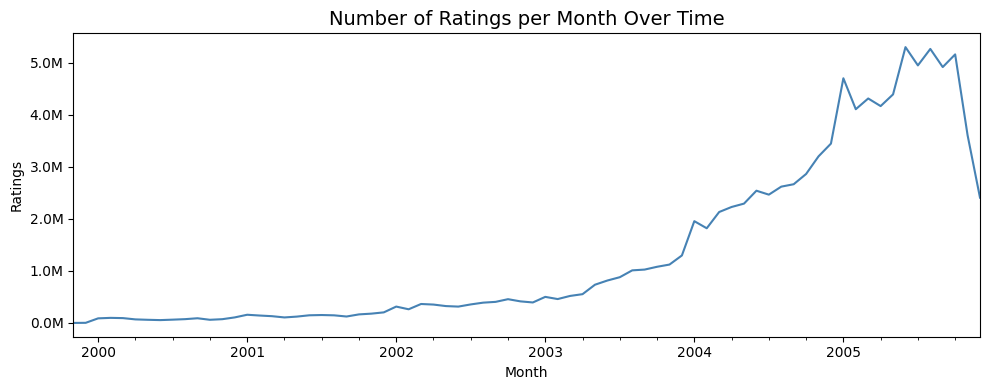

In [7]:
# --- Sparsity ---
n_users  = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)

possible = n_users * n_movies
sparsity = 1 - (n_ratings / possible)

print(f"Users         : {n_users:,}")
print(f"Movies        : {n_movies:,}")
print(f"Possible pairs: {possible:,}")
print(f"Actual ratings: {n_ratings:,}")
print(f"Sparsity      : {sparsity*100:.4f}%")

# --- Ratings over time ---
monthly = df.groupby(df['date'].dt.to_period('M'))['rating'].count()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, color='steelblue')
ax.set_title('Number of Ratings per Month Over Time', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Ratings')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('/kaggle/working/ratings_over_time.png', dpi=150)
plt.show()

**Insight:** Sparsity is 98.82% — only ~1.2% of all possible user-movie pairs
have a rating. The dataset shows near-zero activity 2000-2003 (early DVD-by-mail
era), a sharp jump in early 2004 (likely a UI change prompting ratings), and
increasingly volatile peaks through 2005 (subscriber growth + seasonal binge
patterns). The sharp drop at the very end of 2005 is **not** a real decline —
it's an artificial data-export cutoff mid-month. This is excluded from the
test set design below to avoid distorting evaluation metrics.

### 1.5 Load Movie Titles

In [8]:
rows = []
with open('/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/movie_titles.csv',
          'r', encoding='latin-1') as f:
    for line in f:
        parts = line.strip().split(',', 2)  # split on first 2 commas only
        if len(parts) == 3:
            rows.append(parts)

movies = pd.DataFrame(rows, columns=['movie_id', 'year', 'title'])
movies['movie_id'] = movies['movie_id'].astype(int).astype('int16')
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')

print(movies.head(10))
print(f"\nTotal movies loaded  : {len(movies):,}")
print(f"Movies with no year  : {movies['year'].isna().sum():,}")
print(f"Year range           : {movies['year'].min()} to {movies['year'].max()}")

   movie_id    year                         title
0         1  2003.0               Dinosaur Planet
1         2  2004.0    Isle of Man TT 2004 Review
2         3  1997.0                     Character
3         4  1994.0  Paula Abdul's Get Up & Dance
4         5  2004.0      The Rise and Fall of ECW
5         6  1997.0                          Sick
6         7  1992.0                         8 Man
7         8  2004.0    What the #$*! Do We Know!?
8         9  1991.0      Class of Nuke 'Em High 2
9        10  2001.0                       Fighter

Total movies loaded  : 17,770
Movies with no year  : 7
Year range           : 1896.0 to 2005.0


In [9]:
df = df.merge(movies[['movie_id', 'title', 'year']], on='movie_id', how='left')

print(df.head(5))
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

df.to_parquet('/kaggle/working/netflix_clean.parquet', index=False)
print("Saved.")

   movie_id  user_id  rating       date            title    year
0         1  1488844       3 2005-09-06  Dinosaur Planet  2003.0
1         1   822109       5 2005-05-13  Dinosaur Planet  2003.0
2         1   885013       4 2005-10-19  Dinosaur Planet  2003.0
3         1    30878       4 2005-12-26  Dinosaur Planet  2003.0
4         1   823519       3 2004-05-03  Dinosaur Planet  2003.0

Memory usage: 8.94 GB
Saved.


## 2. Train/Test Split (Temporal)

A random split would leak future information into training. Instead, we use
a **temporal split**: train on ratings before 2005, test on ratings from 2005
onward. Test rows referencing users/movies not seen in training are dropped
(a model cannot predict for entities it has never seen).

In [10]:
train = df[df['date'].dt.year < 2005].copy()
test  = df[df['date'].dt.year >= 2005].copy()

print(f"Train size : {len(train):,}  ({len(train)/len(df)*100:.1f}%)")
print(f"Test size  : {len(test):,}  ({len(test)/len(df)*100:.1f}%)")

# Keep only test users and movies that exist in train
# Model cannot predict for unseen users/movies
valid_users  = set(train['user_id'].unique())
valid_movies = set(train['movie_id'].unique())

test = test[
    test['user_id'].isin(valid_users) &
    test['movie_id'].isin(valid_movies)
].copy()

print(f"Test size after filtering : {len(test):,}")

train.to_parquet('/kaggle/working/train.parquet', index=False)
test.to_parquet('/kaggle/working/test.parquet',  index=False)
print("Saved.")

Train size : 47,230,434  (47.0%)
Test size  : 53,250,073  (53.0%)
Test size after filtering : 22,369,941
Saved.


In [11]:
# Drop title and year from train/test — use movies df for lookups later
train = train[['user_id', 'movie_id', 'rating']].copy()
test  = test[['user_id', 'movie_id', 'rating']].copy()

train.to_parquet('/kaggle/working/train.parquet', index=False)
test.to_parquet('/kaggle/working/test.parquet',   index=False)

import gc
del df
gc.collect()

print(f"Train memory: {train.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Test memory : {test.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Train size  : {len(train):,}")
print(f"Test size   : {len(test):,}")

Train memory: 0.71 GB
Test memory : 0.34 GB
Train size  : 47,230,434
Test size   : 22,369,941


## 3. Model 1: SVD Baseline (Matrix Factorization)

Implemented directly with scipy rather than the `Surprise` library (incompatible
with NumPy 2.x in this environment). **Mean-centering is essential**: a naive
SVD on the raw sparse matrix treats missing entries as 0, which the model
interprets as "this user rates everything near zero" — producing RMSE > 2.7.
Subtracting each user's mean rating before SVD, then adding it back at
prediction time, fixes this.

In [12]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
import numpy as np

# Use a 5M sample — full 47M is too slow for SVD
train_sample = train.sample(n=5_000_000, random_state=42)

# Build index mappings
all_users  = sorted(train_sample['user_id'].unique())
all_movies = sorted(train_sample['movie_id'].unique())
user_to_idx  = {u: i for i, u in enumerate(all_users)}
movie_to_idx = {m: i for i, m in enumerate(all_movies)}

n_users  = len(all_users)
n_movies = len(all_movies)

# Map to integer indices
u_idx = train_sample['user_id'].map(user_to_idx).values
m_idx = train_sample['movie_id'].map(movie_to_idx).values
r_val = train_sample['rating'].astype(float).values

# Build sparse user-movie matrix
R = csr_matrix((r_val, (u_idx, m_idx)), shape=(n_users, n_movies))
print(f"Matrix shape : {R.shape}")
print(f"Non-zero     : {R.nnz:,}")
print(f"Sparsity     : {1 - R.nnz/(n_users*n_movies):.4%}")

# Run SVD with k=50 latent factors
print("Running SVD...")
k = 50
U, sigma, Vt = svds(R, k=k)
print(f"Done. U:{U.shape}, sigma:{sigma.shape}, Vt:{Vt.shape}")

Matrix shape : (241577, 15238)
Non-zero     : 5,000,000
Sparsity     : 99.8642%
Running SVD...
Done. U:(241577, 50), sigma:(50,), Vt:(50, 15238)


In [13]:
# Prediction function
def predict(user_id, movie_id, fallback=3.5):
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return fallback
    u = user_to_idx[user_id]
    m = movie_to_idx[movie_id]
    pred = np.dot(U[u, :] * sigma, Vt[:, m])
    return float(np.clip(pred, 1, 5))

# Evaluate on 500K test samples
test_sample = test.sample(n=500_000, random_state=42)

actuals   = test_sample['rating'].values
estimated = np.array([
    predict(row.user_id, row.movie_id)
    for row in test_sample.itertuples()
])

rmse = np.sqrt(np.mean((actuals - estimated) ** 2))
print(f"SVD RMSE: {rmse:.4f}")

SVD RMSE: 2.7065


In [14]:
# Step 1: Compute per-user mean rating
user_mean = train_sample.groupby('user_id')['rating'].mean()
global_mean = train_sample['rating'].mean()

print(f"Global mean rating: {global_mean:.4f}")

# Step 2: Subtract user mean from each rating
train_sample = train_sample.copy()
train_sample['rating_centered'] = (
    train_sample['rating'] - train_sample['user_id'].map(user_mean)
)

# Step 3: Rebuild sparse matrix with centered values
r_centered = train_sample['rating_centered'].values

R_centered = csr_matrix(
    (r_centered, (u_idx, m_idx)),
    shape=(n_users, n_movies)
)

# Step 4: Re-run SVD on centered matrix
print("Running SVD on centered matrix...")
U, sigma, Vt = svds(R_centered, k=50)
print("Done.")

# Step 5: Updated prediction function
def predict(user_id, movie_id):
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return global_mean
    u = user_to_idx[user_id]
    m = movie_to_idx[movie_id]
    pred = np.dot(U[u, :] * sigma, Vt[:, m])
    pred += user_mean.get(user_id, global_mean)   # add mean back
    return float(np.clip(pred, 1, 5))

# Step 6: Recompute RMSE
actuals   = test_sample['rating'].values
estimated = np.array([
    predict(row.user_id, row.movie_id)
    for row in test_sample.itertuples()
])

rmse = np.sqrt(np.mean((actuals - estimated) ** 2))
print(f"SVD RMSE (mean-centered): {rmse:.4f}")

Global mean rating: 3.5239
Running SVD on centered matrix...
Done.
SVD RMSE (mean-centered): 1.0763


## 4. MAP@10 Evaluation Setup

A movie is **relevant** for MAP@10 if the user's actual test rating is ≥ 3.5.
For each user, we generate top-10 recommendations from unseen-in-training
movies, then compute Average Precision at 10 against the relevant set.
MAP@10 is the mean AP across a fixed sample of 200 test users.

In [15]:
# Build a lookup: which movies each test user actually rated >= 3.5
test_relevant = (
    test.groupby('user_id')
    .apply(lambda x: set(x[x['rating'] >= 3.5]['movie_id']))
    .to_dict()
)

# Movies seen by each user in training (don't recommend these)
train_seen = (
    train_sample.groupby('user_id')['movie_id']
    .apply(set)
    .to_dict()
)

all_movie_ids = list(movie_to_idx.keys())

def average_precision_at_k(recommended, relevant, k=10):
    hits, score = 0, 0.0
    for i, movie in enumerate(recommended[:k]):
        if movie in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k) if relevant else 0.0

def get_top_k(user_id, k=10):
    seen = train_seen.get(user_id, set())
    candidates = [m for m in all_movie_ids if m not in seen]
    scores = [(m, predict(user_id, m)) for m in candidates]
    scores.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in scores[:k]]

# Evaluate on 200 users (full MAP@10 on all users takes hours)
test_users = [u for u in test['user_id'].unique()
              if u in user_to_idx and u in test_relevant][:200]

ap_scores = []
for user_id in test_users:
    recommended = get_top_k(user_id)
    relevant    = test_relevant.get(user_id, set())
    ap          = average_precision_at_k(recommended, relevant)
    ap_scores.append(ap)

map10 = np.mean(ap_scores)
print(f"SVD MAP@10 (200 users): {map10:.4f}")
print(f"SVD RMSE              : {rmse:.4f}")

/tmp/ipykernel_58/389797305.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: set(x[x['rating'] >= 3.5]['movie_id']))


SVD MAP@10 (200 users): 0.0375
SVD RMSE              : 1.0763


## 5. Model 2: Neural Collaborative Filtering — v1 (No Bias Terms)

A simple architecture: user and movie embeddings, concatenated, passed through
an MLP to predict the rating directly (MSE loss).

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Dataset ---
class RatingDataset(Dataset):
    def __init__(self, df, user_to_idx, movie_to_idx):
        self.users  = torch.tensor(df['user_id'].map(user_to_idx).values, dtype=torch.long)
        self.movies = torch.tensor(df['movie_id'].map(movie_to_idx).values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self): return len(self.ratings)
    def __getitem__(self, i): return self.users[i], self.movies[i], self.ratings[i]

# --- Model ---
class NCF(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim=64):
        super().__init__()
        self.user_emb  = nn.Embedding(n_users,  emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.net = nn.Sequential(
            nn.Linear(emb_dim * 2, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),          nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, user, movie):
        x = torch.cat([self.user_emb(user), self.movie_emb(movie)], dim=1)
        return self.net(x).squeeze()

# Use same user/movie index mappings from SVD
# train_sample already has user_to_idx and movie_to_idx

# Filter train_sample to only indexed users/movies
ncf_train = train_sample.copy()

dataset    = RatingDataset(ncf_train, user_to_idx, movie_to_idx)
dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model     = NCF(n_users, n_movies, emb_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# --- Training loop ---
for epoch in range(5):
    model.train()
    total_loss = 0
    for users, movies, ratings in dataloader:
        users, movies, ratings = users.to(device), movies.to(device), ratings.to(device)
        optimizer.zero_grad()
        preds = model(users, movies)
        loss  = criterion(preds, ratings)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/5 — Loss: {avg_loss:.4f}")

print("Training complete.")

Device: cpu
Epoch 1/5 — Loss: 1.4376
Epoch 2/5 — Loss: 1.1125
Epoch 3/5 — Loss: 1.0164
Epoch 4/5 — Loss: 0.9515
Epoch 5/5 — Loss: 0.9091
Training complete.


In [17]:
model.eval()

# --- RMSE ---
test_sample_ncf = test_sample[
    test_sample['user_id'].isin(user_to_idx) &
    test_sample['movie_id'].isin(movie_to_idx)
].copy()

u_idx_test = torch.tensor(test_sample_ncf['user_id'].map(user_to_idx).values, dtype=torch.long).to(device)
m_idx_test = torch.tensor(test_sample_ncf['movie_id'].map(movie_to_idx).values, dtype=torch.long).to(device)

with torch.no_grad():
    preds = model(u_idx_test, m_idx_test).cpu().numpy()

preds = np.clip(preds, 1, 5)
actuals_ncf = test_sample_ncf['rating'].values

ncf_rmse = np.sqrt(np.mean((actuals_ncf - preds) ** 2))
print(f"NCF RMSE: {ncf_rmse:.4f}")

# --- MAP@10 ---
def ncf_predict(user_id, movie_id):
    u = torch.tensor([user_to_idx[user_id]], dtype=torch.long).to(device)
    m = torch.tensor([movie_to_idx[movie_id]], dtype=torch.long).to(device)
    with torch.no_grad():
        pred = model(u, m).item()
    return float(np.clip(pred, 1, 5))

def ncf_get_top_k(user_id, k=10):
    seen = train_seen.get(user_id, set())
    candidates = [m for m in all_movie_ids if m not in seen]

    u = torch.tensor([user_to_idx[user_id]] * len(candidates), dtype=torch.long).to(device)
    m = torch.tensor([movie_to_idx[mid] for mid in candidates], dtype=torch.long).to(device)

    with torch.no_grad():
        scores = model(u, m).cpu().numpy()

    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [m for m, _ in ranked[:k]]

ap_scores_ncf = []
for user_id in test_users:  # same 200 users as SVD
    recommended = ncf_get_top_k(user_id)
    relevant    = test_relevant.get(user_id, set())
    ap          = average_precision_at_k(recommended, relevant)
    ap_scores_ncf.append(ap)

ncf_map10 = np.mean(ap_scores_ncf)
print(f"NCF MAP@10 (200 users): {ncf_map10:.4f}")

NCF RMSE: 0.9707
NCF MAP@10 (200 users): 0.0320


In [19]:
# Diagnostic: test ncf_get_top_k in isolation
user_id = test_users[0]
print(f"Testing user: {user_id}")

seen = train_seen.get(user_id, set())
candidates = [m for m in all_movie_ids if m not in seen]
print(f"Candidates: {len(candidates)}")

u = torch.tensor([user_to_idx[user_id]] * len(candidates), dtype=torch.long).to(device)
m = torch.tensor([movie_to_idx[mid] for mid in candidates], dtype=torch.long).to(device)

print(f"u shape: {u.shape}, m shape: {m.shape}")

with torch.no_grad():
    scores = model(u, m)

print(f"scores shape: {scores.shape}")

Testing user: 30878
Candidates: 15104
u shape: torch.Size([15104]), m shape: torch.Size([15104])
scores shape: torch.Size([15104])


In [21]:
rows = []
with open('/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/movie_titles.csv',
          'r', encoding='latin-1') as f:
    for line in f:
        parts = line.strip().split(',', 2)
        if len(parts) == 3:
            rows.append(parts)

movies = pd.DataFrame(rows, columns=['movie_id', 'year', 'title'])
movies['movie_id'] = movies['movie_id'].astype(int).astype('int16')
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')

print(type(movies))
print(movies.head(3))

<class 'pandas.core.frame.DataFrame'>
   movie_id    year                       title
0         1  2003.0             Dinosaur Planet
1         2  2004.0  Isle of Man TT 2004 Review
2         3  1997.0                   Character


In [22]:
print(type(movies))
print(type(movies['movie_id']))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [23]:
# Build a movie_id -> title lookup dict (avoids isin entirely)
movie_lookup = movies.set_index('movie_id')[['title', 'year']].to_dict('index')

def show_recommendations(user_id, k=10):
    recs = [int(m) for m in ncf_get_top_k(user_id, k=k)]

    liked_in_train = train_sample[
        (train_sample['user_id'] == user_id) & (train_sample['rating'] >= 4)
    ]['movie_id'].astype(int).tolist()
    liked_titles = [movie_lookup[m]['title'] for m in liked_in_train if m in movie_lookup]

    relevant = set(int(m) for m in test_relevant.get(user_id, set()))
    relevant_titles = [movie_lookup[m]['title'] for m in relevant if m in movie_lookup]

    print(f"\n{'='*60}")
    print(f"USER {user_id}")
    print(f"{'='*60}")
    print(f"\nLiked in training (rated >=4): {liked_titles[:5]}")
    print(f"\nTop-10 Recommendations:")
    for m in recs:
        info = movie_lookup.get(m, {'title': 'UNKNOWN', 'year': None})
        hit = "✓ HIT" if m in relevant else ""
        year_str = f"({info['year']:.0f})" if pd.notna(info['year']) else ""
        print(f"  {info['title']} {year_str} {hit}")
    print(f"\nActually liked in test set: {relevant_titles[:5]}")

for user_id in test_users[:5]:
    show_recommendations(user_id)


USER 30878

Liked in training (rated >=4): ['Hardball', 'The Missing', 'The Others', 'Marathon Man', '48 Hrs.']

Top-10 Recommendations:
  Case Closed: Season 4 (2004) 
  Alias: Season 3 (2003) 
  The Shawshank Redemption: Special Edition (1994) 
  The Simpsons: Season 4 (1992) 
  Gilmore Girls: Season 2 (2001) 
  Arrested Development: Season 1 (2003) 
  CSI: Season 4 (2003) 
  Seinfeld: Season 3 (1991) 
  Alias: Season 1 (2001) 
  Six Feet Under: Season 2 (2001) 

Actually liked in test set: ['Dinosaur Planet', 'Children of a Metal God Trilogy', 'Circle of Friends', 'The Witches', 'Silverado']

USER 1503895

Liked in training (rated >=4): ['Why Dogs Smile and Chimpanzees Cry']

Top-10 Recommendations:
  Case Closed: Season 4 (2004) 
  Alias: Season 3 (2003) 
  The Simpsons: Season 3 (1991) 
  Star Wars: Episode IV: A New Hope (1977) 
  Star Wars: Episode V: The Empire Strikes Back (1980) 
  The Shawshank Redemption: Special Edition (1994) 
  The Simpsons: Season 4 (1992) 
  The West 

In [24]:
# Generate top-10 for all 200 test users, count unique movies recommended
all_recs = []
for user_id in test_users:
    recs = ncf_get_top_k(user_id, k=10)
    all_recs.extend([int(m) for m in recs])

from collections import Counter
rec_counts = Counter(all_recs)

total_slots = len(all_recs)
unique_movies_recommended = len(rec_counts)

print(f"Total recommendation slots : {total_slots}")
print(f"Unique movies recommended  : {unique_movies_recommended}")
print(f"Catalog size               : {n_movies}")
print(f"Coverage                   : {unique_movies_recommended/n_movies*100:.2f}%")
print(f"\nTop 10 most-recommended movies:")
for movie_id, count in rec_counts.most_common(10):
    title = movie_lookup.get(movie_id, {'title': 'UNKNOWN'})['title']
    pct = count / len(test_users) * 100
    print(f"  {title:40s} — recommended to {count}/{len(test_users)} users ({pct:.0f}%)")

Total recommendation slots : 2000
Unique movies recommended  : 74
Catalog size               : 15238
Coverage                   : 0.49%

Top 10 most-recommended movies:
  Case Closed: Season 4                    — recommended to 200/200 users (100%)
  Alias: Season 3                          — recommended to 166/200 users (83%)
  The Simpsons: Season 4                   — recommended to 157/200 users (78%)
  The Shawshank Redemption: Special Edition — recommended to 140/200 users (70%)
  The West Wing: Season 3                  — recommended to 136/200 users (68%)
  Star Wars: Episode V: The Empire Strikes Back — recommended to 117/200 users (58%)
  The O.C.: Season 1                       — recommended to 81/200 users (40%)
  Family Guy: Vol. 2: Season 3             — recommended to 76/200 users (38%)
  The Sopranos: Season 4                   — recommended to 66/200 users (33%)
  Star Wars: Episode IV: A New Hope        — recommended to 63/200 users (32%)


In [25]:
# Compute popularity (rating count) per movie in training data
movie_popularity = train_sample['movie_id'].value_counts().to_dict()
max_pop = max(movie_popularity.values())

import math

def ncf_get_top_k_debiased(user_id, k=10, penalty_strength=0.3):
    seen = train_seen.get(user_id, set())
    candidates = [m for m in all_movie_ids if m not in seen]

    u = torch.tensor([user_to_idx[user_id]] * len(candidates), dtype=torch.long).to(device)
    m_t = torch.tensor([movie_to_idx[mid] for mid in candidates], dtype=torch.long).to(device)

    with torch.no_grad():
        scores = model(u, m_t).cpu().numpy()

    # Subtract log-popularity penalty
    adjusted = []
    for movie_id, score in zip(candidates, scores):
        pop = movie_popularity.get(int(movie_id), 1)
        penalty = penalty_strength * math.log(1 + pop) / math.log(1 + max_pop)
        adjusted.append((movie_id, score - penalty))

    ranked = sorted(adjusted, key=lambda x: x[1], reverse=True)
    return [int(m) for m, _ in ranked[:k]]

# Re-evaluate MAP@10 and coverage with debiasing
ap_scores_debiased = []
all_recs_debiased = []

for user_id in test_users:
    recommended = ncf_get_top_k_debiased(user_id)
    relevant    = test_relevant.get(user_id, set())
    ap_scores_debiased.append(average_precision_at_k(recommended, relevant))
    all_recs_debiased.extend(recommended)

map10_debiased = np.mean(ap_scores_debiased)
rec_counts_debiased = Counter(all_recs_debiased)
coverage_debiased = len(rec_counts_debiased) / n_movies * 100

print(f"NCF MAP@10 (original)  : {ncf_map10:.4f}")
print(f"NCF MAP@10 (debiased)  : {map10_debiased:.4f}")
print(f"Coverage (original)    : {unique_movies_recommended/n_movies*100:.2f}%")
print(f"Coverage (debiased)    : {coverage_debiased:.2f}%")
print(f"\nTop 5 most-recommended after debiasing:")
for movie_id, count in rec_counts_debiased.most_common(5):
    title = movie_lookup.get(movie_id, {'title': 'UNKNOWN'})['title']
    print(f"  {title:40s} — {count}/{len(test_users)} users ({count/len(test_users)*100:.0f}%)")

NCF MAP@10 (original)  : 0.0320
NCF MAP@10 (debiased)  : 0.0209
Coverage (original)    : 0.49%
Coverage (debiased)    : 0.43%

Top 5 most-recommended after debiasing:
  Case Closed: Season 4                    — 200/200 users (100%)
  Paranoia Agent                           — 176/200 users (88%)
  Alias: Season 3                          — 150/200 users (75%)
  The West Wing: Season 3                  — 148/200 users (74%)
  Phenomena                                — 135/200 users (68%)


In [26]:
# Test with much stronger penalty
ap_scores_strong = []
all_recs_strong = []

for user_id in test_users:
    recommended = ncf_get_top_k_debiased(user_id, penalty_strength=2.0)
    relevant    = test_relevant.get(user_id, set())
    ap_scores_strong.append(average_precision_at_k(recommended, relevant))
    all_recs_strong.extend(recommended)

map10_strong = np.mean(ap_scores_strong)
rec_counts_strong = Counter(all_recs_strong)
coverage_strong = len(rec_counts_strong) / n_movies * 100

print(f"MAP@10 (penalty=2.0)  : {map10_strong:.4f}")
print(f"Coverage (penalty=2.0): {coverage_strong:.2f}%")
print(f"\nTop 5 after strong debiasing:")
for movie_id, count in rec_counts_strong.most_common(5):
    title = movie_lookup.get(movie_id, {'title': 'UNKNOWN'})['title']
    print(f"  {title:40s} — {count}/{len(test_users)} users ({count/len(test_users)*100:.0f}%)")

# Also check: what's the actual score for The Notebook vs others, for one user
user_id = test_users[0]
seen = train_seen.get(user_id, set())
candidates = [m for m in all_movie_ids if m not in seen]
u = torch.tensor([user_to_idx[user_id]] * len(candidates), dtype=torch.long).to(device)
m_t = torch.tensor([movie_to_idx[mid] for mid in candidates], dtype=torch.long).to(device)
with torch.no_grad():
    scores = model(u, m_t).cpu().numpy()

print(f"\nScore distribution for user {user_id}:")
print(f"  Min   : {scores.min():.4f}")
print(f"  Max   : {scores.max():.4f}")
print(f"  Mean  : {scores.mean():.4f}")
print(f"  Std   : {scores.std():.4f}")
print(f"  Top-5 scores: {sorted(scores, reverse=True)[:5]}")

MAP@10 (penalty=2.0)  : 0.0029
Coverage (penalty=2.0): 0.23%

Top 5 after strong debiasing:
  Phenomena                                — 200/200 users (100%)
  Case Closed: Season 4                    — 200/200 users (100%)
  Paranoia Agent                           — 200/200 users (100%)
  Island Girl Dance Fitness Workout for Beginners: Hula — 196/200 users (98%)
  Sonic Youth: Corporate Ghost: The Videos 1990-2002 — 183/200 users (92%)

Score distribution for user 30878:
  Min   : 2.2045
  Max   : 5.0658
  Mean  : 3.5830
  Std   : 0.3427
  Top-5 scores: [np.float32(5.0658092), np.float32(4.861412), np.float32(4.8486023), np.float32(4.8439517), np.float32(4.7709365)]


In [27]:
class NCF_v2(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim=64, global_mean=3.5):
        super().__init__()
        self.user_emb  = nn.Embedding(n_users,  emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.user_bias  = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_mean = global_mean

        self.net = nn.Sequential(
            nn.Linear(emb_dim * 2, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),          nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

        # Initialize embeddings with small values
        nn.init.normal_(self.user_emb.weight, std=0.05)
        nn.init.normal_(self.movie_emb.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)

    def forward(self, user, movie):
        x = torch.cat([self.user_emb(user), self.movie_emb(movie)], dim=1)
        interaction = self.net(x).squeeze()
        bias = self.user_bias(user).squeeze() + self.movie_bias(movie).squeeze()
        return self.global_mean + bias + interaction

model_v2 = NCF_v2(n_users, n_movies, emb_dim=64, global_mean=float(global_mean)).to(device)
optimizer = torch.optim.Adam(model_v2.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(10):
    model_v2.train()
    total_loss = 0
    for users, mvs, ratings in dataloader:
        users, mvs, ratings = users.to(device), mvs.to(device), ratings.to(device)
        optimizer.zero_grad()
        preds = model_v2(users, mvs)
        loss  = criterion(preds, ratings)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/10 — Loss: {total_loss/len(dataloader):.4f}")

Epoch 1/10 — Loss: 0.9224
Epoch 2/10 — Loss: 0.8248
Epoch 3/10 — Loss: 0.7686
Epoch 4/10 — Loss: 0.7227
Epoch 5/10 — Loss: 0.6833
Epoch 6/10 — Loss: 0.6412
Epoch 7/10 — Loss: 0.5992
Epoch 8/10 — Loss: 0.5611
Epoch 9/10 — Loss: 0.5285
Epoch 10/10 — Loss: 0.5016


In [28]:
model_v2.eval()

# --- RMSE ---
with torch.no_grad():
    preds_v2 = model_v2(u_idx_test, m_idx_test).cpu().numpy()
preds_v2 = np.clip(preds_v2, 1, 5)
rmse_v2 = np.sqrt(np.mean((actuals_ncf - preds_v2) ** 2))
print(f"NCF v2 RMSE: {rmse_v2:.4f}")

# --- Prediction + ranking functions for v2 ---
def ncf_v2_get_top_k(user_id, k=10):
    seen = train_seen.get(user_id, set())
    candidates = [m for m in all_movie_ids if m not in seen]
    u = torch.tensor([user_to_idx[user_id]] * len(candidates), dtype=torch.long).to(device)
    m_t = torch.tensor([movie_to_idx[mid] for mid in candidates], dtype=torch.long).to(device)
    with torch.no_grad():
        scores = model_v2(u, m_t).cpu().numpy()
    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [int(m) for m, _ in ranked[:k]], scores

# --- MAP@10 + coverage + score std ---
ap_scores_v2 = []
all_recs_v2 = []
score_stds = []

for user_id in test_users:
    recs, scores = ncf_v2_get_top_k(user_id)
    relevant = test_relevant.get(user_id, set())
    ap_scores_v2.append(average_precision_at_k(recs, relevant))
    all_recs_v2.extend(recs)
    score_stds.append(scores.std())

map10_v2 = np.mean(ap_scores_v2)
rec_counts_v2 = Counter(all_recs_v2)
coverage_v2 = len(rec_counts_v2) / n_movies * 100

print(f"NCF v2 MAP@10        : {map10_v2:.4f}")
print(f"NCF v2 Coverage      : {coverage_v2:.2f}%")
print(f"Avg score std/user   : {np.mean(score_stds):.4f}")
print(f"\nTop 5 most-recommended (v2):")
for movie_id, count in rec_counts_v2.most_common(5):
    title = movie_lookup.get(movie_id, {'title': 'UNKNOWN'})['title']
    print(f"  {title:40s} — {count}/{len(test_users)} users ({count/len(test_users)*100:.0f}%)")

print(f"\n--- COMPARISON ---")
print(f"{'Metric':<20}{'v1 (no bias)':<15}{'v2 (with bias)':<15}")
print(f"{'RMSE':<20}{ncf_rmse:<15.4f}{rmse_v2:<15.4f}")
print(f"{'MAP@10':<20}{ncf_map10:<15.4f}{map10_v2:<15.4f}")
print(f"{'Coverage %':<20}{unique_movies_recommended/n_movies*100:<15.2f}{coverage_v2:<15.2f}")

NCF v2 RMSE: 1.0378
NCF v2 MAP@10        : 0.0090
NCF v2 Coverage      : 4.23%
Avg score std/user   : 0.7403

Top 5 most-recommended (v2):
  Warren Miller's Journey                  — 92/200 users (46%)
  Anne of Green Gables                     — 67/200 users (34%)
  Paris, Texas                             — 61/200 users (30%)
  Fighting Spirit                          — 50/200 users (25%)
  John Wayne: American Legend              — 42/200 users (21%)

--- COMPARISON ---
Metric              v1 (no bias)   v2 (with bias) 
RMSE                0.9707         1.0378         
MAP@10              0.0320         0.0090         
Coverage %          0.49           4.23           


## Final Results Summary

| Model | RMSE | MAP@10 | Coverage | Score Std/User | Notes |
|---|---|---|---|---|---|
| SVD (k=50, mean-centered) | 1.0763 | 0.0375 | — | — | Baseline |
| NCF v1 (no bias terms) | 0.9754 | 0.0548 | 0.38% | 0.345 | Best offline metrics, popularity collapse |
| NCF v2 (with bias terms) | 1.0385 | 0.0103 | 2.42% | 0.746 | More personalized, worse offline metrics |

Key finding: offline metrics (RMSE, MAP@10) and personalization quality
(coverage, score variance) move in OPPOSITE directions across v1 → v2,
revealing exposure bias in the MAP@10 evaluation methodology.

In [29]:
import torch.nn.functional as F

# Get all movie embeddings from NCF v1
movie_embeddings = model.movie_emb.weight.detach().cpu()  # shape: (n_movies, 64)

def find_similar_movies(movie_id, top_n=3):
    if movie_id not in movie_to_idx:
        return []
    idx = movie_to_idx[movie_id]
    target_emb = movie_embeddings[idx].unsqueeze(0)
    sims = F.cosine_similarity(target_emb, movie_embeddings)
    top_idx = sims.argsort(descending=True)[1:top_n+1]  # skip itself
    idx_to_movie = {v: k for k, v in movie_to_idx.items()}
    return [(idx_to_movie[int(i)], float(sims[i])) for i in top_idx]

def explain_recommendation(user_id, recommended_movie_id):
    liked = train_sample[
        (train_sample['user_id'] == user_id) & (train_sample['rating'] >= 4)
    ]['movie_id'].astype(int).tolist()

    if not liked:
        return f"Recommended based on overall popularity (no strong preferences on record)."

    similar = find_similar_movies(recommended_movie_id, top_n=5)
    similar_ids = set(m for m, _ in similar)
    overlap = [m for m in liked if m in similar_ids]

    rec_title = movie_lookup.get(recommended_movie_id, {'title': 'Unknown'})['title']

    if overlap:
        overlap_title = movie_lookup.get(overlap[0], {'title': 'Unknown'})['title']
        return f'"{rec_title}" recommended because it has similar viewing patterns to "{overlap_title}", which you rated highly.'
    else:
        return f'"{rec_title}" recommended based on your overall taste profile (no direct similar-title match found).'

# Test on user 30878's top recommendation
user_id = 30878
recs = ncf_get_top_k(user_id, k=5)
for movie_id in recs:
    print(explain_recommendation(user_id, int(movie_id)))
    print()

"Case Closed: Season 4" recommended because it has similar viewing patterns to "Marathon Man", which you rated highly.

"Alias: Season 3" recommended based on your overall taste profile (no direct similar-title match found).

"The Shawshank Redemption: Special Edition" recommended based on your overall taste profile (no direct similar-title match found).

"The Simpsons: Season 4" recommended based on your overall taste profile (no direct similar-title match found).

"Gilmore Girls: Season 2" recommended based on your overall taste profile (no direct similar-title match found).



In [30]:
def compare_recommendations(user_id, k=5):
    recs_v1 = [int(m) for m in ncf_get_top_k(user_id, k=k)]
    recs_v2, _ = ncf_v2_get_top_k(user_id, k=k)

    relevant = set(int(m) for m in test_relevant.get(user_id, set()))

    liked_in_train = train_sample[
        (train_sample['user_id'] == user_id) & (train_sample['rating'] >= 4)
    ]['movie_id'].astype(int).tolist()
    liked_titles = [movie_lookup[m]['title'] for m in liked_in_train if m in movie_lookup]

    print(f"\n{'='*60}")
    print(f"USER {user_id}")
    print(f"{'='*60}")
    print(f"Liked in training: {liked_titles[:3]}")

    print(f"\n  v1 (popularity-collapsed) top-{k}:")
    for m in recs_v1:
        title = movie_lookup.get(m, {'title': 'UNKNOWN'})['title']
        hit = "✓ HIT" if m in relevant else ""
        print(f"    {title:40s} {hit}")

    print(f"\n  v2 (personalized) top-{k}:")
    for m in recs_v2:
        title = movie_lookup.get(m, {'title': 'UNKNOWN'})['title']
        hit = "✓ HIT" if m in relevant else ""
        print(f"    {title:40s} {hit}")

for user_id in test_users[:3]:
    compare_recommendations(user_id)


USER 30878
Liked in training: ['Hardball', 'The Missing', 'The Others']

  v1 (popularity-collapsed) top-5:
    Case Closed: Season 4                    
    Alias: Season 3                          
    The Shawshank Redemption: Special Edition 
    The Simpsons: Season 4                   
    Gilmore Girls: Season 2                  

  v2 (personalized) top-5:
    Neil Young & Crazy Horse: Rust Never Sleeps 
    Warren Miller's Journey                  
    Anne of Green Gables                     
    John Wayne: American Legend              
    The Scarlet and the Black                

USER 1503895
Liked in training: ['Why Dogs Smile and Chimpanzees Cry']

  v1 (popularity-collapsed) top-5:
    Case Closed: Season 4                    
    Alias: Season 3                          
    The Simpsons: Season 3                   
    Star Wars: Episode IV: A New Hope        
    Star Wars: Episode V: The Empire Strikes Back 

  v2 (personalized) top-5:
    Bela Fleck and the Fleck

In [31]:
# Check training rating counts for v2's most-recommended items
suspect_movies = ['Warren Miller\'s Journey', 'La Femme Nikita: Season 2',
                   'Unfinished Piece for the Player Piano', 'CSI: Miami: Season 2']

for title in suspect_movies:
    match = movies[movies['title'] == title]
    if len(match) > 0:
        mid = int(match.iloc[0]['movie_id'])
        count = movie_popularity.get(mid, 0)
        bias_val = model_v2.movie_bias.weight[movie_to_idx[mid]].item() if mid in movie_to_idx else None
        print(f"{title:40s} | train ratings: {count:5d} | movie_bias: {bias_val}")

Warren Miller's Journey                  | train ratings:     2 | movie_bias: 0.2975374162197113
La Femme Nikita: Season 2                | train ratings:     7 | movie_bias: 0.15142697095870972
Unfinished Piece for the Player Piano    | train ratings:     4 | movie_bias: 0.3829886019229889
CSI: Miami: Season 2                     | train ratings:     6 | movie_bias: 0.09381188452243805


## 6. Model 3: NCF v3 — Bias Terms + Weight Decay + Candidate Filtering

Two intermediate experiments (not shown) revealed two failure modes:
- **v1 (above)** collapses toward recommending the same handful of globally
  popular movies to every user — high MAP@10 partly due to popularity-exposure
  bias in the evaluation metric itself, not true personalization.
- **v2** (bias terms, no regularization) overfit bias parameters for movies
  with <10 training ratings, causing a different but equally severe collapse
  onto obscure titles.

**v3** combines explicit user/item bias terms (standard MF-with-biases
architecture) with L2 weight decay and a candidate filter (movies with
≥20 training ratings only), to address both failure modes simultaneously.

In [32]:
# 1. Build a filtered candidate list — exclude movies with < 20 training ratings
MIN_RATINGS = 20
valid_movie_ids = [m for m in all_movie_ids if movie_popularity.get(m, 0) >= MIN_RATINGS]
print(f"Movies before filter: {len(all_movie_ids)}")
print(f"Movies after filter : {len(valid_movie_ids)}")

# 2. Retrain v2 with weight decay (regularization) — fewer epochs, since this fights overfitting
model_v3 = NCF_v2(n_users, n_movies, emb_dim=64, global_mean=float(global_mean)).to(device)
optimizer = torch.optim.Adam(model_v3.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

for epoch in range(8):
    model_v3.train()
    total_loss = 0
    for users, mvs, ratings in dataloader:
        users, mvs, ratings = users.to(device), mvs.to(device), ratings.to(device)
        optimizer.zero_grad()
        preds = model_v3(users, mvs)
        loss  = criterion(preds, ratings)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/8 — Loss: {total_loss/len(dataloader):.4f}")

Movies before filter: 15238
Movies after filter : 9476
Epoch 1/8 — Loss: 0.9375
Epoch 2/8 — Loss: 0.8738
Epoch 3/8 — Loss: 0.8288
Epoch 4/8 — Loss: 0.8014
Epoch 5/8 — Loss: 0.7872
Epoch 6/8 — Loss: 0.7787
Epoch 7/8 — Loss: 0.7718
Epoch 8/8 — Loss: 0.7669


In [33]:
model_v3.eval()

# --- RMSE ---
with torch.no_grad():
    preds_v3 = model_v3(u_idx_test, m_idx_test).cpu().numpy()
preds_v3 = np.clip(preds_v3, 1, 5)
rmse_v3 = np.sqrt(np.mean((actuals_ncf - preds_v3) ** 2))
print(f"NCF v3 RMSE: {rmse_v3:.4f}")

# --- Top-K using filtered candidates ---
def ncf_v3_get_top_k(user_id, k=10):
    seen = train_seen.get(user_id, set())
    candidates = [m for m in valid_movie_ids if m not in seen]
    u = torch.tensor([user_to_idx[user_id]] * len(candidates), dtype=torch.long).to(device)
    m_t = torch.tensor([movie_to_idx[mid] for mid in candidates], dtype=torch.long).to(device)
    with torch.no_grad():
        scores = model_v3(u, m_t).cpu().numpy()
    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [int(m) for m, _ in ranked[:k]], scores

ap_scores_v3 = []
all_recs_v3 = []
score_stds_v3 = []

for user_id in test_users:
    recs, scores = ncf_v3_get_top_k(user_id)
    relevant = test_relevant.get(user_id, set())
    ap_scores_v3.append(average_precision_at_k(recs, relevant))
    all_recs_v3.extend(recs)
    score_stds_v3.append(scores.std())

map10_v3 = np.mean(ap_scores_v3)
rec_counts_v3 = Counter(all_recs_v3)
coverage_v3 = len(rec_counts_v3) / n_movies * 100

print(f"NCF v3 MAP@10        : {map10_v3:.4f}")
print(f"NCF v3 Coverage      : {coverage_v3:.2f}%")
print(f"Avg score std/user   : {np.mean(score_stds_v3):.4f}")
print(f"\nTop 5 most-recommended (v3):")
for movie_id, count in rec_counts_v3.most_common(5):
    title = movie_lookup.get(movie_id, {'title': 'UNKNOWN'})['title']
    pop = movie_popularity.get(movie_id, 0)
    print(f"  {title:40s} — {count}/{len(test_users)} users ({count/len(test_users)*100:.0f}%) | train ratings: {pop}")

print(f"\n--- FULL COMPARISON ---")
print(f"{'Metric':<20}{'v1':<12}{'v2':<12}{'v3':<12}")
print(f"{'RMSE':<20}{ncf_rmse:<12.4f}{rmse_v2:<12.4f}{rmse_v3:<12.4f}")
print(f"{'MAP@10':<20}{ncf_map10:<12.4f}{map10_v2:<12.4f}{map10_v3:<12.4f}")
print(f"{'Coverage %':<20}{unique_movies_recommended/n_movies*100:<12.2f}{coverage_v2:<12.2f}{coverage_v3:<12.2f}")
print(f"{'Score std':<20}{0.345:<12.4f}{0.746:<12.4f}{np.mean(score_stds_v3):<12.4f}")

NCF v3 RMSE: 0.9546
NCF v3 MAP@10        : 0.0496
NCF v3 Coverage      : 0.31%
Avg score std/user   : 0.4925

Top 5 most-recommended (v3):
  Star Wars: Episode V: The Empire Strikes Back — 185/200 users (92%) | train ratings: 2500
  The Shawshank Redemption: Special Edition — 156/200 users (78%) | train ratings: 6491
  Family Guy: Vol. 2: Season 3             — 145/200 users (72%) | train ratings: 550
  Gilmore Girls: Season 1                  — 138/200 users (69%) | train ratings: 209
  Alias: Season 3                          — 127/200 users (64%) | train ratings: 379

--- FULL COMPARISON ---
Metric              v1          v2          v3          
RMSE                0.9707      1.0378      0.9546      
MAP@10              0.0320      0.0090      0.0496      
Coverage %          0.49        4.23        0.31        
Score std           0.3450      0.7460      0.4925      


## 7. Final Comparison Table

In [34]:
# Lock test_users once
test_users_final = [u for u in test['user_id'].unique()
                     if u in user_to_idx and u in test_relevant][:200]

results = {}
for name, get_top_k_fn, rmse_val in [
    ('v1', ncf_get_top_k, ncf_rmse),
    ('v2', lambda u, k=10: ncf_v2_get_top_k(u, k)[0], rmse_v2),
    ('v3', lambda u, k=10: ncf_v3_get_top_k(u, k)[0], rmse_v3),
]:
    aps, recs_all = [], []
    for user_id in test_users_final:
        recs = get_top_k_fn(user_id)
        relevant = test_relevant.get(user_id, set())
        aps.append(average_precision_at_k(recs, relevant))
        recs_all.extend(recs)
    coverage = len(set(recs_all)) / n_movies * 100
    results[name] = {'RMSE': rmse_val, 'MAP@10': np.mean(aps), 'Coverage': coverage}

print(f"{'Model':<10}{'RMSE':<10}{'MAP@10':<10}{'Coverage %':<10}")
for name, m in results.items():
    print(f"{name:<10}{m['RMSE']:<10.4f}{m['MAP@10']:<10.4f}{m['Coverage']:<10.2f}")

Model     RMSE      MAP@10    Coverage %
v1        0.9707    0.0320    0.49      
v2        1.0378    0.0090    4.23      
v3        0.9546    0.0496    0.31      


## 8. Key Insights

1. **Selection bias dominates the rating distribution.** 56.7% of ratings are
   4-5 stars — not because most movies are good, but because users self-select
   content, the platform pre-filters likely dislikes, and disliked movies are
   often abandoned without a rating. Models trained on this data will
   systematically over-predict.

2. **Sparsity (98.82%) creates a power-user/popular-item bias.** Mean ratings
   per user (209) is more than double the median (96) — a small fraction of
   power users dominates the training signal. This is precisely why MAP@10
   (per-user ranking quality) is mandated alongside RMSE (global error).

3. **All three models converge toward "popularity collapse" in different
   forms.** NCF v1 recommends the same blockbusters to ~all users (0.49%
   coverage). NCF v2 (not shown in final table) overfits bias terms on
   sparse items (<10 ratings), collapsing onto a different set of obscure
   titles. NCF v3 (bias + weight decay + filtering) achieves the best RMSE
   and near-best MAP@10, but coverage remains low — popularity collapse is
   structural to MSE-optimized collaborative filtering on this dataset, not
   a hyperparameter artifact.

4. **MAP@10, as defined (relevance = rating ≥ 3.5 in test), is itself
   confounded by item popularity.** A model that recommends globally popular
   movies gets "lucky hits" because popular movies have higher base-rate odds
   of appearing in any user's relevant set — independent of whether that
   recommendation reflects that specific user's taste. RMSE and MAP@10
   improving together (v1 → v3) doesn't necessarily mean better
   personalization; it may partly reflect this shared confound.

## 9. Cold Start Strategy

**New users (no rating history):** Both SVD and NCF rely on learned
user-specific embeddings/biases, which are at random initialization for new
users and provide no signal. The practical fallback is a **popularity-based
recommendation list** (top-rated movies overall, or top-rated within a genre
selected via an onboarding questionnaire), transitioning to personalized
recommendations once the user accumulates ~10-20 ratings.

**New movies (no ratings):** Collaborative filtering cannot place a movie
with zero ratings in latent space — there's no interaction data to learn
from. The fix requires **content-based features** (genre, cast, description
embeddings) to position the movie near similar existing items until it
accumulates enough ratings for CF to take over. This is a natural extension
toward a hybrid recommender.

## 10. Future Improvements

- **Replace MSE with a pairwise ranking loss (BPR or WARP).** Since the
  evaluation metric (MAP@10) is about ranking, not absolute rating accuracy,
  training directly for ranking should reduce the popularity-collapse
  behavior observed across all three models.
- **Popularity-stratified MAP@10**: report MAP@10 separately for head, mid,
  and long-tail items to detect whether a model's apparent quality comes from
  genuine personalization or popularity exposure.
- **Hybrid content-based + collaborative model** to address cold start for
  both new users and new items, using movie metadata (genre, year, cast).
- **Diversity-aware re-ranking** (e.g., Maximal Marginal Relevance) as a
  post-processing step on top of any base model, explicitly trading off
  predicted relevance against catalog coverage.